In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns 

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

import warnings
warnings.filterwarnings('ignore') #경고 메시지 무시

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping #오버피팅 방지 -> 학습이 더이상 안되면 조기종료
from tensorflow.keras.callbacks import ReduceLROnPlateau #학습이안되면 Learning rate를 일정 양 줄여줌

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


In [29]:
#NMAE 평가.
def NMAE_FUNC (true, pred, S):
    
    # 판다스 데이터프레임 기준
    # true : 실제발전량
    # pred : 예측발전량
    # S : 발전용량(kW)
    
    true_values = true.loc[true.values > S * 0.1, :]
    pred_values = pred.loc[true_values.index, :]
    
    AE = sum(abs(true_values.values - pred_values.values))
    NAE = AE / S
    NMAE = 100 * (NAE / len(true_values))
    
    return NMAE[0]

------------------------입력데이터, 태양광데이터 분석 및전처리----------------------------

In [30]:
#예측을 위한 ASOS데이터 불러오기
path = './ASOS_data/'
list = []

for file in os.listdir(path):
    list.append(pd.read_csv(path+file,encoding='cp949'))

asos = pd.concat(list)
asos.index = pd.to_datetime(asos['일시'])

In [31]:
#온도 데이터
path_ = './ASOS_ondo/'
list_= []
for file in os.listdir(path_):
    list_.append(pd.read_csv(path_+file,encoding='cp949'))
asos_ = pd.concat(list_)
asos_.index = pd.to_datetime(asos_['일시'])

In [32]:

asos_ = asos_.drop(columns=['지점명','일시','지점']) 
asos_ = asos_.sort_index()

In [33]:
#필요없는 데이터 삭제 (일사는 관측량이 없음)
asos = asos.drop(columns=['지점명','일시','지점','일사(MJ/m2)']) 
asos = asos.sort_index()



In [34]:
asos = pd.merge(left=asos, right=asos_, left_index=True, right_index=True)

In [35]:
#발전량 데이터 불러오기
solar=pd.read_csv('./DATA/태양광 발전량 데이터.csv',encoding='UTF-8')
solar.index = pd.to_datetime(solar['일시'])
solar = solar.drop(columns=['일시'])


In [36]:
result = pd.merge(left=asos, right=solar, left_index=True, right_index=True)

In [37]:
result

,일조(hr),전운량(10분위),지면온도(°C),AC_출력_1,AC_출력_2
일시,,,,,
2020-01-01 01:00:00,NaN,0.0,-3.0,NaN,NaN
2020-01-01 02:00:00,NaN,0.0,-2.4,NaN,NaN
2020-01-01 03:00:00,NaN,0.0,-3.0,NaN,NaN
2020-01-01 04:00:00,NaN,0.0,-2.8,NaN,NaN
2020-01-01 05:00:00,NaN,0.0,-3.5,NaN,NaN
...,...,...,...,...,...
2023-03-31 19:00:00,0.0,0.0,11.0,NaN,NaN
2023-03-31 20:00:00,NaN,0.0,9.3,NaN,NaN
2023-03-31 21:00:00,NaN,0.0,8.3,NaN,NaN


In [38]:
#결측치 있는지 확인
result.isnull().sum()

일조(hr)       12882
전운량(10분위)      192
지면온도(°C)         0
AC_출력_1      15107
AC_출력_2      15279
dtype: int64

출력 데이터가 07시 ~ 17까지밖에 없음, 일조 데이터도 비슷한 경향을 보임
전운량 데이터가 제대로 평가되지 않을 것을 고려해 데이터가 있는 시간대만 파악해봄

In [39]:
#1.모든 결측치 0으로
result_fill = result.fillna(0)

#2.일조,출력이 없는 시간대 18시~06시의 행 제거
result_drop = result.fillna(0)
result_drop = result_drop[result_drop['AC_출력_1'] != 0.0 ] 

#solar_drop['전운량(10분위)'] = solar_drop['전운량(10분위)'].fillna(0)

In [40]:
result_drop

,일조(hr),전운량(10분위),지면온도(°C),AC_출력_1,AC_출력_2
일시,,,,,
2020-01-01 07:00:00,0.0,0.0,-3.6,3.678750,3.832857
2020-01-01 08:00:00,0.2,0.0,-3.2,10.687500,13.486667
2020-01-01 09:00:00,1.0,0.0,-0.8,21.321667,25.706666
2020-01-01 10:00:00,1.0,0.0,1.5,28.073333,32.997500
2020-01-01 11:00:00,1.0,0.0,5.7,29.853333,36.303334
...,...,...,...,...,...
2023-03-31 14:00:00,1.0,5.0,39.8,27.386667,29.505833
2023-03-31 15:00:00,1.0,1.0,35.9,17.643334,19.521667
2023-03-31 16:00:00,1.0,0.0,30.0,7.915833,8.749167


-----------------------------------------각 변수별 상관계수 분석--------------------------------------

In [41]:
#상관 계수 분석
result_fill.corr(method='pearson')

,일조(hr),전운량(10분위),지면온도(°C),AC_출력_1,AC_출력_2
일조(hr),1.000000,-0.344904,0.389369,0.706915,0.700772
전운량(10분위),-0.344904,1.000000,0.218001,-0.189057,-0.196098
지면온도(°C),0.389369,0.218001,1.000000,0.402853,0.380744
AC_출력_1,0.706915,-0.189057,0.402853,1.000000,0.961099
AC_출력_2,0.700772,-0.196098,0.380744,0.961099,1.000000


In [42]:
result_drop.corr(method='pearson')


,일조(hr),전운량(10분위),지면온도(°C),AC_출력_1,AC_출력_2
일조(hr),1.000000,-0.583800,0.248694,0.647626,0.635870
전운량(10분위),-0.583800,1.000000,0.137307,-0.360801,-0.367211
지면온도(°C),0.248694,0.137307,1.000000,0.345361,0.294815
AC_출력_1,0.647626,-0.360801,0.345361,1.000000,0.947874
AC_출력_2,0.635870,-0.367211,0.294815,0.947874,1.000000


In [44]:
#폰트설정 맑음고딕
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

Text(0.5, 1.0, 'drop')

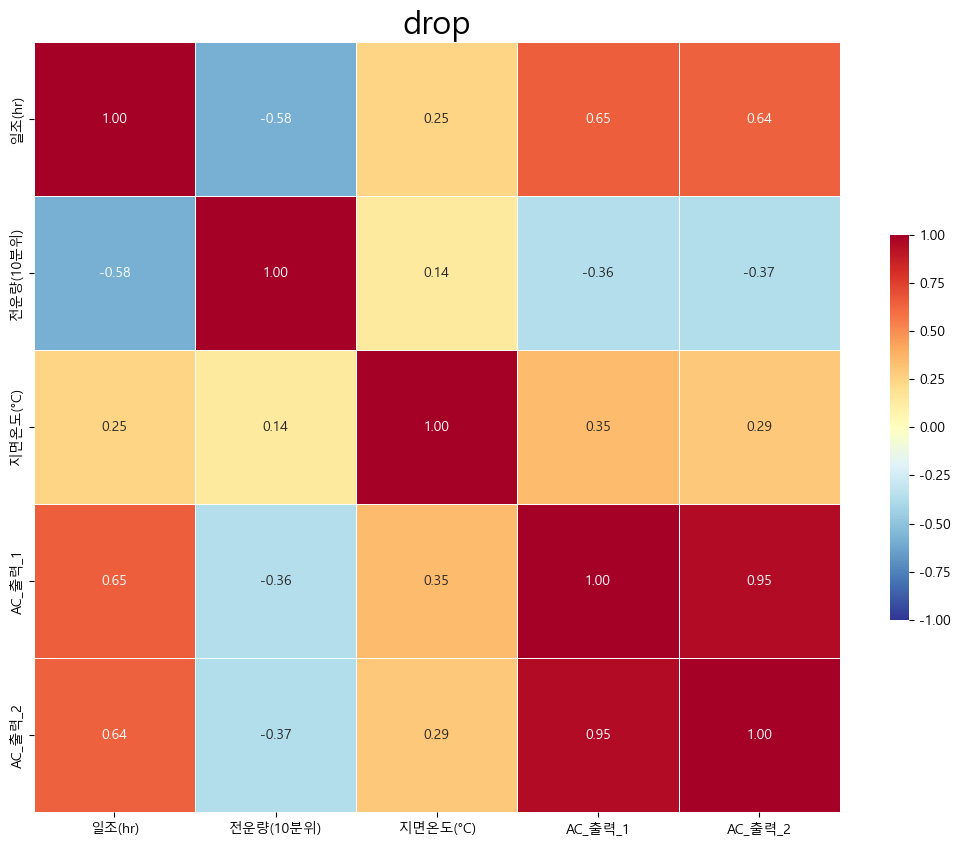

In [45]:
#
plt.figure(figsize = (13,10)) # 그릴 그래프 크기
sns.heatmap(data = result_drop.corr(method = 'pearson'), # 히트맵에 넣을 상관계수 
annot = True,# 히트맵 안에 숫자를 표시할지 여부 
fmt = '.2f', # 소숫점 둘째자리까지 나타냄
linewidths = .5, # 히트맵 사이의 선 굵기
cbar_kws={"shrink": .5}, #우측 컬러바 크기 절반으로 줄이기 
cmap = 'RdYlBu_r', # 히트맵 색상 지정 
vmin = -1, vmax = 1) # 우측 컬러바 min, max 값 설정 
# 히트맵 이름 설정 및 폰트 사이즈 설정
plt.title("drop", fontsize = 23)

Text(0.5, 1.0, 'fill')

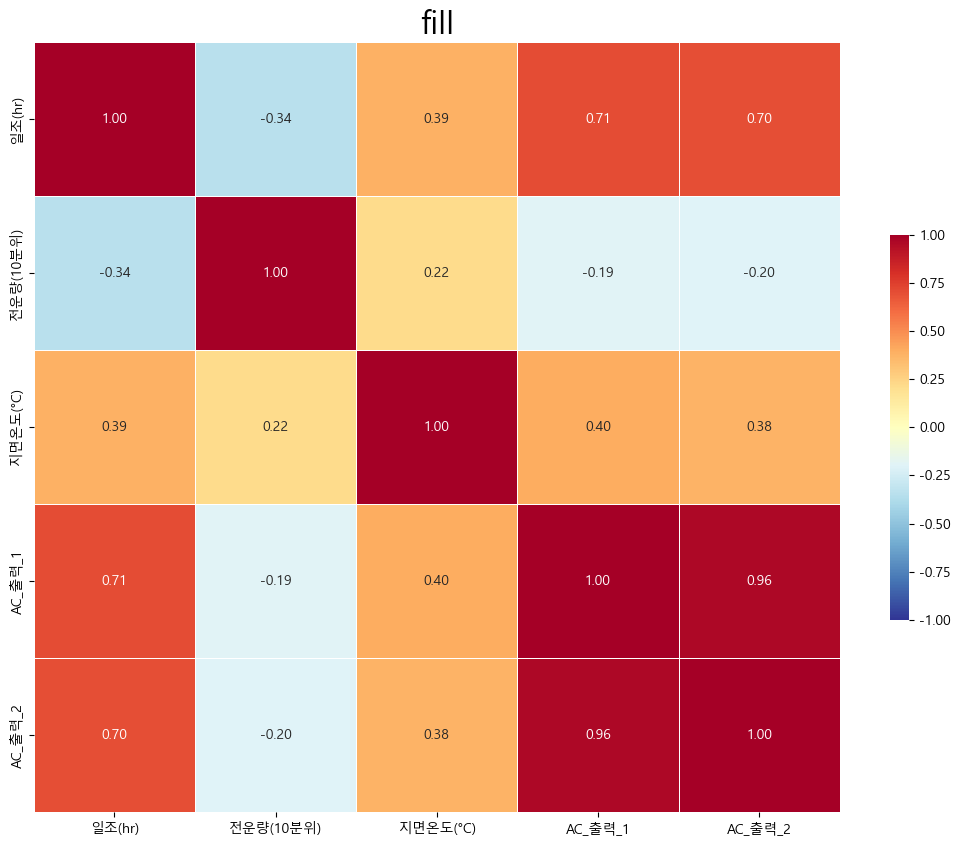

In [46]:
#
plt.figure(figsize = (13,10)) # 그릴 그래프 크기
sns.heatmap(data = result_fill.corr(method = 'pearson'), # 히트맵에 넣을 상관계수 
annot = True,# 히트맵 안에 숫자를 표시할지 여부 
fmt = '.2f', # 소숫점 둘째자리까지 나타냄
linewidths = .5, # 히트맵 사이의 선 굵기
cbar_kws={"shrink": .5}, #우측 컬러바 크기 절반으로 줄이기 
cmap = 'RdYlBu_r', # 히트맵 색상 지정 
vmin = -1, vmax = 1) # 우측 컬러바 min, max 값 설정 
# 히트맵 이름 설정 및 폰트 사이즈 설정
plt.title("fill", fontsize = 23)

두개다 비교를 해봤지만 유의할정도로 상관성을 보인 것은 일조량 (r>=0.65 기준)
---------이제부터 LSTM 시작---------------

In [52]:
result_drop

,일조(hr),전운량(10분위),지면온도(°C),AC_출력_1,AC_출력_2
일시,,,,,
2020-01-01 07:00:00,0.0,0.0,-3.6,3.678750,3.832857
2020-01-01 08:00:00,0.2,0.0,-3.2,10.687500,13.486667
2020-01-01 09:00:00,1.0,0.0,-0.8,21.321667,25.706666
2020-01-01 10:00:00,1.0,0.0,1.5,28.073333,32.997500
2020-01-01 11:00:00,1.0,0.0,5.7,29.853333,36.303334
...,...,...,...,...,...
2023-03-31 14:00:00,1.0,5.0,39.8,27.386667,29.505833
2023-03-31 15:00:00,1.0,1.0,35.9,17.643334,19.521667
2023-03-31 16:00:00,1.0,0.0,30.0,7.915833,8.749167


In [84]:
#result-drop
raw_data_f = result_fill.drop(columns=['전운량(10분위)','지면온도(°C)']) #필요없는 인자 삭제
# 예측 결과를 저장할 딕셔너리 선언
y_pred_tr_dict = {}
y_pred_te_dict = {}

In [116]:
#x = raw_data_f.drop(columns=['AC_출력_1', 'AC_출력_2'])

for target in ['AC_출력_1', 'AC_출력_2']: #1,2 두 번 반복
    #훈련데이터 테스트데이터 분리
    split_data = '2022-12-31 23:00:00'
    y= raw_data_f[[target]]

    stockPriceClose=y
    split_date = pd.Timestamp(split_data)

    #학습용 데이터와 테스트용 데이터로 분리
    train_data=pd.DataFrame(stockPriceClose.loc[:split_date,[target]])
    test_data=pd.DataFrame(stockPriceClose.loc[split_date:,[target]])

    #스케일러 데이터를 0~1사이값으로 조정
    scaler = MinMaxScaler()     

    train_sc = scaler.fit_transform(train_data)
    test_sc = scaler.transform(test_data)

    train_sc_df = pd.DataFrame(train_sc, columns=['Scaled'], index=train_data.index)
    test_sc_df = pd.DataFrame(test_sc, columns=['Scaled'], index=test_data.index)
    
    #뒤에 24 단위로 볼 수있다.
    for i in range(1, 25):
        train_sc_df ['Scaled_{}'.format(i)]=train_sc_df ['Scaled'].shift(i)
        test_sc_df ['Scaled_{}'.format(i)]=test_sc_df ['Scaled'].shift(i)

   
    #종속변수, 독립변수 나누기
    x_train=train_sc_df.fillna(0).drop('Scaled', axis=1)
    y_train=train_sc_df.fillna(0)[['Scaled']]

    x_test=test_sc_df.fillna(0).drop('Scaled', axis=1)
    y_test=test_sc_df.fillna(0)[['Scaled']]

    x_train=x_train.values
    x_test=x_test.values

    y_train=y_train.values
    y_test=y_test.values

    #LSTM 모델에 맞게 데이터 셋 변형
    x_train_t = x_train.reshape(x_train.shape[0], 24,1)  #앞에서 설정한 단위 바뀔시 바뀜
    x_test_t = x_test.reshape(x_test.shape[0], 24, 1)  #앞에서 설정한 단위 바뀔시 바뀜

    from keras.layers import LSTM 
    from keras.models import Sequential 
    from keras.layers import Dense 
    import keras.backend as K 
    from keras.callbacks import EarlyStopping 

    K.clear_session() 
    # Sequeatial Model
    model = Sequential() 
    # 첫번째 LSTM 레이어 처음 숫자는 메모리 셀의 수
    model.add(LSTM(24,return_sequences=True, input_shape=(24, 1))) #앞에서 설정한 단위 바뀔시 바뀜
    # 두번째 LSTM 레이어
    model.add(LSTM(42,return_sequences=False))  
    # 예측값 1개
    model.add(Dense(1, activation='relu')) #sigmoid 해볼까
    # 손실함수 지정 - 예측 값과 실제 값의 차이를 계산한다. MSE가 사용된다. 
    # 최적화기 지정 - 일반적으로 adam을 사용한다.
    model.compile(loss='mean_squared_error', optimizer='adam') 
    model.summary()

    #손실 값(loss)를 모니터링해서 성능이 더이상 좋아지지 않으면 epoch를 중단한다.
    #vervose=1은 화면에 출력
    early_stop = EarlyStopping(monitor='loss', patience=5, verbose=1)

    #epochs는 훈련 반복 횟수를 지정하고 batch_size는 한 번 훈련할 때 입력되는 데이터 크기를 지정한다.
    model.fit(x_train_t, y_train, epochs=30,
            batch_size=20, verbose=1, callbacks=[early_stop])

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    
   # 훈련된 모델 저장
    import pickle
    with open(f'./{target}_model.pickle', 'wb') as fw:
        pickle.dump(model, fw)
        

    #train 평가
    y_pred = model.predict(x_train_t)
    y_pred = np.array(y_pred).reshape(-1, 1)
    print('MSE : ', mean_squared_error(y_train, y_pred))
    print('MAE : ', mean_absolute_error(y_train, y_pred))
    print('R2 : ', r2_score(y_train, y_pred))

    #train 예측결과 딕셔너리 저장

    y_pred_ori = scaler.inverse_transform(y_pred)
    y_pred_ori = pd.DataFrame(y_pred_ori, index=range(len(y_train))) #문제 ndarray형이라 인덱스 접근이 안댐

    y_pred_tr_dict[target] = y_pred_ori

    #test 평가
    y_pred = model.predict(x_test_t)
    y_pred = np.array(y_pred).reshape(-1, 1)
    print('MSE : ', mean_squared_error(y_test, y_pred))
    print('MAE : ', mean_absolute_error(y_test, y_pred))
    print('R2 : ', r2_score(y_test, y_pred))

    #test 예측결과 딕셔너리 저장
    y_pred_ori = scaler.inverse_transform(y_pred)
    y_pred_ori = pd.DataFrame(data=y_pred_ori, index=range(len(y_test)))
        
    y_pred_te_dict[target] = y_pred_ori

    # Test 데이터 시각화
    # plt.figure(figsize=(20, 5))

    # idx=len(y_test)
    # plt.plot(y_test.index[-idx:], y_scaler.inverse_transform(y_test_scaled)[-idx:], label='Observed')
    # plt.plot(y_test.index[-idx:], y_scaler.inverse_transform(y_pred)[-idx:], label='Predicted')
    # plt.legend()
    # plt.grid()
    # plt.show()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 24, 24)            2496      
                                                                 
 lstm_1 (LSTM)               (None, 42)                11256     
                                                                 
 dense (Dense)               (None, 1)                 43        
                                                                 
Total params: 13795 (53.89 KB)
Trainable params: 13795 (53.89 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/30
1308/1308 [==============================] - 15s 9ms/step - loss: 0.0677
Epoch 2/30
1308/1308 [==============================] - 11s 9ms/step - loss: 0.0677
Epoch 3/30
1308/1308 [==============================] - 12s 9ms/step - loss: 0.0677
Epoch 4/30
1308/1308 [==========

KeyboardInterrupt: 

---------------------NMAE 평가------------------------

In [115]:
# 훈련된 모델 저장
import pickle
with open(f'./{target}_model.pickle', 'wb') as fw:
    pickle.dump(model, fw)

In [86]:
tr_list = []
te_list = []

for key in y_pred_tr_dict.keys():
    tr_list.append(y_pred_tr_dict[key])
    te_list.append(y_pred_te_dict[key])

#결합
pred_tr = pd.concat(tr_list, axis=1)
pred_te = pd.concat(te_list, axis=1)

#두가지 예측 발전량 합하기
pred_tr.columns = ['예측_발전량_1', '예측_발전량_2']
pred_te.columns = ['예측_발전량_1', '예측_발전량_2']
pred_tr['예측총발전량'] = pred_tr.sum(axis=1)
pred_te['예측총발전량'] = pred_te.sum(axis=1)

#train , test 나누기
true_tr = raw_data_f[['AC_출력_1', 'AC_출력_2']].loc[raw_data_f.index <= split_data, :]
true_te = raw_data_f[['AC_출력_1', 'AC_출력_2']].loc[raw_data_f.index > split_data, :]

#index에 있는 시간데이터 없애기
true_tr.reset_index(drop=True,inplace=True)
true_te.reset_index(drop=True,inplace=True)

true_tr['총발전량'] = true_tr.sum(axis=1)
true_te['총발전량'] = true_te.sum(axis=1)

S_total = 100 # 총 설비용량 : 100kW

# Train 예측총발전량에 대한 NMAE(%)
tr_NMAE = NMAE_FUNC(true=true_tr[['총발전량']], pred=pred_tr[['예측총발전량']], S=S_total)
print('Train NMAE(%) :', tr_NMAE, '%')

# Test 예측총발전량에 대한 NMAE(%)
te_NMAE = NMAE_FUNC(true=true_te[['총발전량']], pred=pred_te[['예측총발전량']], S=S_total)
print('Test NMAE(%) :', te_NMAE, '%')

Train NMAE(%) : 5.7773659996586195 %
Test NMAE(%) : 13.678927316708359 %


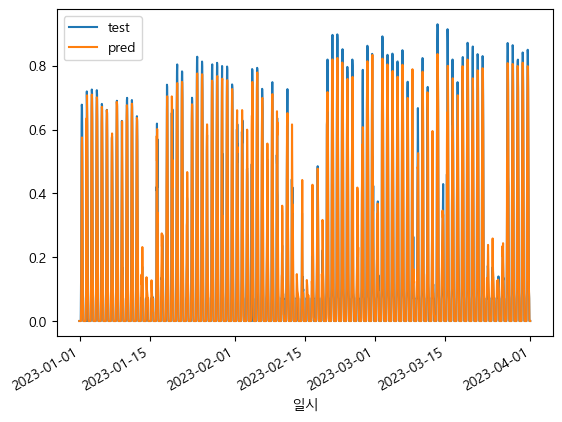

In [94]:
t_df=test_sc_df.dropna()
y_test_df=pd.DataFrame(y_test, columns=['close'], index=test_sc_df.index)
y_pred_df=pd.DataFrame(y_pred, columns=['close'], index=test_sc_df.index)
ax1=y_test_df.plot()
y_pred_df.plot(ax=ax1)
plt.legend(['test','pred'])

In [110]:
# Train, Test 결과 저장
pred_tr.to_csv('./예측 결과 제출 양식/Train 예측 결과.csv', encoding='utf-8-sig')
pred_te.to_csv('./예측 결과 제출 양식/Test 예측 결과.csv', encoding='utf-8-sig')

# Train, Test NMAE(%) 결과 저장
pd.DataFrame([tr_NMAE, te_NMAE], index=['Train_NMAE(%)', 'Test_NMAE(%)']).T.to_csv('./예측 결과 제출 양식/NMAE_결과.csv', index=False, encoding='utf-8-sig')

------------------------------------

AttributeError: 'numpy.ndarray' object has no attribute 'isnull'